# Semana 10: Aprendizaje No Supervisado - Energia y Sustentabilidad

**Integrante:** Thalia Gonzalez  
**Tema:** Impacto ambiental de la energia  
**Objetivo:** identificar grupos de plantas de generacion electrica segun capacidad instalada y perfil tecnologico, usando PCA, K-Means y DBSCAN.

Este notebook adapta el ejemplo de la guia al dataset `global_power_plant_database` preparado durante el proyecto.

## 1. Librerias y sesion Spark

Se utiliza PySpark para la preparacion y K-Means; scikit-learn se utiliza para DBSCAN porque MLlib no lo incorpora de forma nativa.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from sklearn.cluster import DBSCAN

spark = SparkSession.builder.appName("Semana10_Clustering_Energia_Thalia").getOrCreate()
spark.sparkContext.setLogLevel("WARN")
print("Spark listo para Semana 10")

Spark listo para Semana 10


## 2. Carga de datos

Por defecto se usa el CSV de 500 registros de Thalia, que permite ejecutar la practica de forma reproducible. Si la coleccion grupal de MongoDB ya esta disponible, cambia `USAR_MONGODB` a `True` y configura las variables del entorno.

In [2]:
USAR_MONGODB = False
MONGO_URI = os.getenv("MONGO_URI", "mongodb://database:27017/")
MONGO_DATABASE = os.getenv("MONGO_DATABASE", "proyecto_bigdata")
MONGO_COLLECTION = os.getenv("MONGO_COLLECTION", "energia_sustentabilidad")

if USAR_MONGODB:
    df = (spark.read.format("mongodb")
          .option("spark.mongodb.read.connection.uri", MONGO_URI)
          .option("database", MONGO_DATABASE)
          .option("collection", MONGO_COLLECTION)
          .load())
    fuente_cargada = f"MongoDB: {MONGO_DATABASE}.{MONGO_COLLECTION}"
else:
    rutas = [Path("Energy/datos_auditoria_global.csv"), Path("../../Energy/datos_auditoria_global.csv")]
    ruta_csv = next(ruta for ruta in rutas if ruta.exists())
    df = spark.read.option("header", True).option("inferSchema", True).csv(str(ruta_csv))
    fuente_cargada = str(ruta_csv)

print("Fuente cargada:", fuente_cargada)
print("Registros originales:", df.count())
df.select("item", "categoria_energia", "tecnologia", "valor", "unidad").show(5, truncate=False)

Fuente cargada: ../../Energy/datos_auditoria_global.csv
Registros originales: 500
+--------------------------------------------------------+-----------------+----------+-----+------+
|item                                                    |categoria_energia|tecnologia|valor|unidad|
+--------------------------------------------------------+-----------------+----------+-----+------+
|Kajaki Hydroelectric Power Plant Afghanistan - Hydro    |Renovable        |Hydro     |33.0 |MW    |
|Kandahar DOG - Solar                                    |Renovable        |Solar     |10.0 |MW    |
|Kandahar JOL - Solar                                    |Renovable        |Solar     |10.0 |MW    |
|Mahipar Hydroelectric Power Plant Afghanistan - Hydro   |Renovable        |Hydro     |66.0 |MW    |
|Naghlu Dam Hydroelectric Power Plant Afghanistan - Hydro|Renovable        |Hydro     |100.0|MW    |
+--------------------------------------------------------+-----------------+----------+-----+------+
only show

## 3. Preparacion de variables para clustering

El dataset energetico no tiene `precio`, `rating` u `opiniones`; sus variables se adaptan al problema real:

- `capacidad_mw`: potencia instalada de la planta (`valor`).
- `frecuencia_tecnologia`: cantidad de plantas de la misma tecnologia en la muestra.
- `es_renovable`: indicador binario de categoria energetica.

Con estas variables se agrupan plantas por magnitud y perfil de tecnologia.

In [3]:
df_base = (df
    .withColumn("capacidad_mw", F.col("valor").cast("double"))
    .filter(F.col("capacidad_mw").isNotNull() & (F.col("capacidad_mw") > 0))
    .filter(F.col("tecnologia").isNotNull() & F.col("categoria_energia").isNotNull()))

frecuencias = df_base.groupBy("tecnologia").agg(F.count("*").alias("frecuencia_tecnologia"))

df_reducido = (df_base.join(frecuencias, "tecnologia", "left")
    .withColumn("es_renovable", F.when(F.col("categoria_energia") == "Renovable", F.lit(1.0)).otherwise(F.lit(0.0)))
    .select("item", "pais", "tecnologia", "categoria_energia", "capacidad_mw", "frecuencia_tecnologia", "es_renovable"))

print("Registros validos para clustering:", df_reducido.count())
df_reducido.show(10, truncate=False)

Registros validos para clustering: 500
+-----------------------------------------------------------------+-----------+----------+-----------------+------------+---------------------+------------+
|item                                                             |pais       |tecnologia|categoria_energia|capacidad_mw|frecuencia_tecnologia|es_renovable|
+-----------------------------------------------------------------+-----------+----------+-----------------+------------+---------------------+------------+
|Kajaki Hydroelectric Power Plant Afghanistan - Hydro             |Afghanistan|Hydro     |Renovable        |33.0        |96                   |1.0         |
|Kandahar DOG - Solar                                             |Afghanistan|Solar     |Renovable        |10.0        |65                   |1.0         |
|Kandahar JOL - Solar                                             |Afghanistan|Solar     |Renovable        |10.0        |65                   |1.0         |
|Mahipar Hydroelect

## 4. Vectorizacion, estandarizacion y PCA

Se estandarizan las variables porque la capacidad en MW tiene una escala mucho mayor que el indicador renovable.

In [4]:
columnas_numericas = ["capacidad_mw", "frecuencia_tecnologia", "es_renovable"]

assembler = VectorAssembler(inputCols=columnas_numericas, outputCol="features")
df_vector = assembler.transform(df_reducido)

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

pca = PCA(k=2, inputCol="scaledFeatures", outputCol="pcaFeatures")
pca_model = pca.fit(df_scaled)
df_pca = pca_model.transform(df_scaled)

varianza = pca_model.explainedVariance.toArray()
print("Varianza explicada PC1 y PC2:", varianza)
print("Varianza acumulada:", round(float(varianza.sum()), 4))
df_pca.select("item", "tecnologia", "capacidad_mw", "pcaFeatures").show(5, truncate=False)

Varianza explicada PC1 y PC2: [0.49598341 0.33730164]
Varianza acumulada: 0.8333
+--------------------------------------------------------+----------+------------+-----------------------------------------+
|item                                                    |tecnologia|capacidad_mw|pcaFeatures                              |
+--------------------------------------------------------+----------+------------+-----------------------------------------+
|Kajaki Hydroelectric Power Plant Afghanistan - Hydro    |Hydro     |33.0        |[0.9243278369573134,-0.42818066253923864]|
|Kandahar DOG - Solar                                    |Solar     |10.0        |[1.4841229245743164,-0.27321369293869235]|
|Kandahar JOL - Solar                                    |Solar     |10.0        |[1.4841229245743164,-0.27321369293869235]|
|Mahipar Hydroelectric Power Plant Afghanistan - Hydro   |Hydro     |66.0        |[0.9046183783276878,-0.32115628317170136]|
|Naghlu Dam Hydroelectric Power Plant Afghan

## 5. Metodo del codo para escoger K

La inercia disminuye cuando aumenta K. Se observa el punto donde la mejora comienza a ser menor para escoger un numero interpretable de clusters.

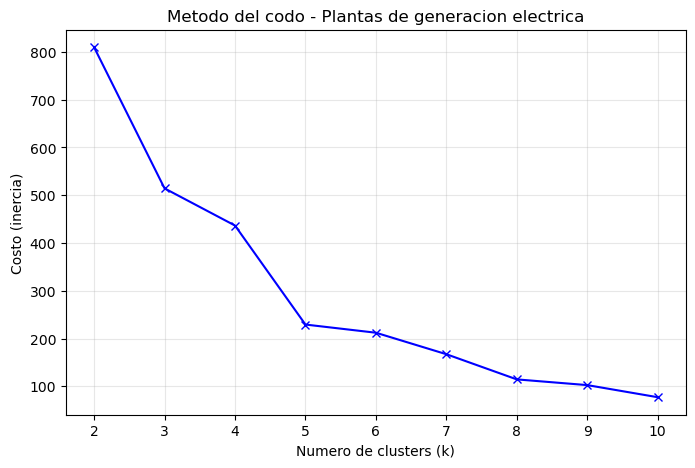

,k,inercia
0,2,809.688355
1,3,514.317251
2,4,436.500778
3,5,229.311548
4,6,212.212173
5,7,167.235816
6,8,114.535215
7,9,102.575068
8,10,77.227005


In [5]:
costos = []
rango_k = list(range(2, 11))

for k in rango_k:
    kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
    modelo = kmeans.fit(df_scaled)
    costos.append(modelo.summary.trainingCost)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, costos, "bx-")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Costo (inercia)")
plt.title("Metodo del codo - Plantas de generacion electrica")
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({"k": rango_k, "inercia": costos})

## 6. K-Means final

Se utiliza `k=3` para separar perfiles interpretables: plantas de baja capacidad, plantas intermedias/frecuentes y plantas de alta capacidad o perfil diferenciado. Si el grafico del codo indica otro valor, se puede cambiar `K_OPTIMO`.

In [6]:
K_OPTIMO = 3
kmeans_final = KMeans(featuresCol="scaledFeatures", k=K_OPTIMO, seed=42)
model_final = kmeans_final.fit(df_pca)
df_clusters = model_final.transform(df_pca)

resumen_kmeans = (df_clusters.groupBy("prediction")
    .agg(
        F.count("item").alias("total_plantas"),
        F.round(F.avg("capacidad_mw"), 2).alias("capacidad_promedio_mw"),
        F.round(F.min("capacidad_mw"), 2).alias("capacidad_minima_mw"),
        F.round(F.max("capacidad_mw"), 2).alias("capacidad_maxima_mw"),
        F.round(F.avg("es_renovable") * 100, 2).alias("porcentaje_renovable")
    ).orderBy("prediction"))

print("Resumen de clusters K-Means:")
resumen_kmeans.show(truncate=False)
df_clusters.select("item", "tecnologia", "categoria_energia", "capacidad_mw", "prediction").show(10, truncate=False)

Resumen de clusters K-Means:
+----------+-------------+---------------------+-------------------+-------------------+--------------------+
|prediction|total_plantas|capacidad_promedio_mw|capacidad_minima_mw|capacidad_maxima_mw|porcentaje_renovable|
+----------+-------------+---------------------+-------------------+-------------------+--------------------+
|0         |229          |77.16                |1.0                |600.0              |86.9                |
|1         |34           |1028.04              |589.0              |2640.0             |17.65               |
|2         |237          |97.96                |1.0                |600.0              |0.0                 |
+----------+-------------+---------------------+-------------------+-------------------+--------------------+

+-----------------------------------------------------------------+----------+-----------------+------------+----------+
|item                                                             |tecnologia|c

### Guardado de pseudo-etiquetas para Semana 12

Se conserva el cluster generado por K-Means como una etiqueta inicial para entrenar modelos supervisados.


In [7]:
RUTA_DATOS_ETIQUETADOS = "/home/jovyan/work/semanas/Semana 10 Aprendizaje No Supervisado/modelos/datos_etiquetados_kmeans"
RUTA_MODELO_KMEANS = "/home/jovyan/work/semanas/Semana 10 Aprendizaje No Supervisado/modelos/kmeans_energia_v1"

df_clusters.write.mode("overwrite").parquet(RUTA_DATOS_ETIQUETADOS)
model_final.write().overwrite().save(RUTA_MODELO_KMEANS)

print("Datos pseudo-etiquetados guardados en:", RUTA_DATOS_ETIQUETADOS)
print("Modelo K-Means guardado en:", RUTA_MODELO_KMEANS)


Datos pseudo-etiquetados guardados en: /home/jovyan/work/semanas/Semana 10 Aprendizaje No Supervisado/modelos/datos_etiquetados_kmeans
Modelo K-Means guardado en: /home/jovyan/work/semanas/Semana 10 Aprendizaje No Supervisado/modelos/kmeans_energia_v1


## 7. Visualizacion de K-Means en espacio PCA

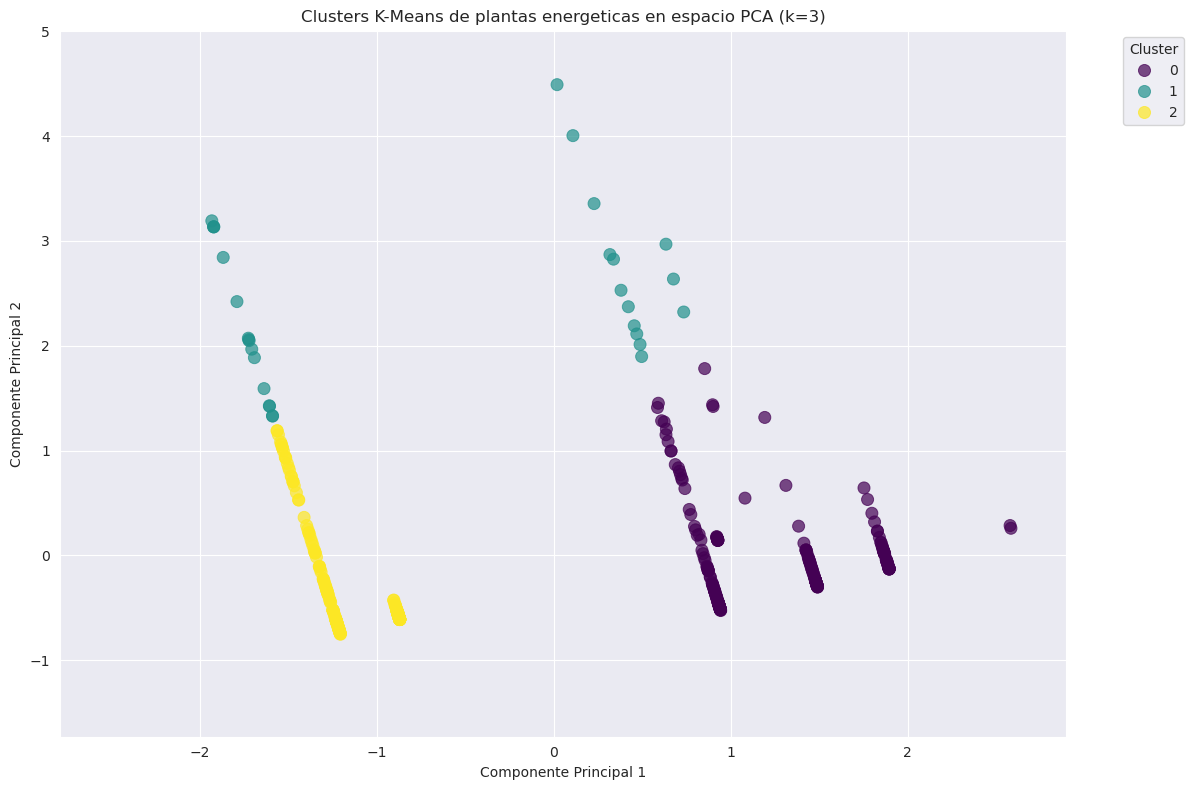

In [8]:
pdf_visual = df_clusters.select("pcaFeatures", "prediction", "tecnologia", "categoria_energia", "capacidad_mw").toPandas()
pdf_visual[["PC1", "PC2"]] = pd.DataFrame(pdf_visual["pcaFeatures"].apply(lambda x: x.toArray()).tolist(), index=pdf_visual.index)

pc1_min, pc1_max = np.percentile(pdf_visual["PC1"], [1, 99])
pc2_min, pc2_max = np.percentile(pdf_visual["PC2"], [1, 99])

plt.figure(figsize=(12, 8))
sns.set_style("darkgrid")
sns.scatterplot(data=pdf_visual, x="PC1", y="PC2", hue="prediction", palette="viridis", s=75, alpha=0.7, edgecolor=None)
plt.xlim(pc1_min - 1, pc1_max + 1)
plt.ylim(pc2_min - 1, pc2_max + 1)
plt.title(f"Clusters K-Means de plantas energeticas en espacio PCA (k={K_OPTIMO})")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. DBSCAN para detectar densidad y outliers

DBSCAN trabaja sobre las coordenadas PCA. Los registros con cluster `-1` se consideran plantas atipicas respecto a los patrones densos de capacidad y tecnologia.

In [9]:
pdf_dbscan = df_pca.select("pcaFeatures", "item", "tecnologia", "categoria_energia", "capacidad_mw").toPandas()
X = np.array(pdf_dbscan["pcaFeatures"].apply(lambda x: x.toArray()).tolist())

dbscan = DBSCAN(eps=0.5, min_samples=5)
pdf_dbscan["cluster_dbscan"] = dbscan.fit_predict(X)
pdf_dbscan[["PC1", "PC2"]] = pd.DataFrame(X, index=pdf_dbscan.index)

resumen_dbscan = (pdf_dbscan.groupby("cluster_dbscan")
                  .agg(total_plantas=("item", "count"), capacidad_promedio_mw=("capacidad_mw", "mean"))
                  .round(2))
print("Resumen DBSCAN (-1 representa ruido/outliers):")
display(resumen_dbscan)
print("Outliers detectados:", int((pdf_dbscan["cluster_dbscan"] == -1).sum()))

Resumen DBSCAN (-1 representa ruido/outliers):


,total_plantas,capacidad_promedio_mw
cluster_dbscan,,
-1,8,1365.02
0,239,113.72
1,253,149.17


Outliers detectados: 8


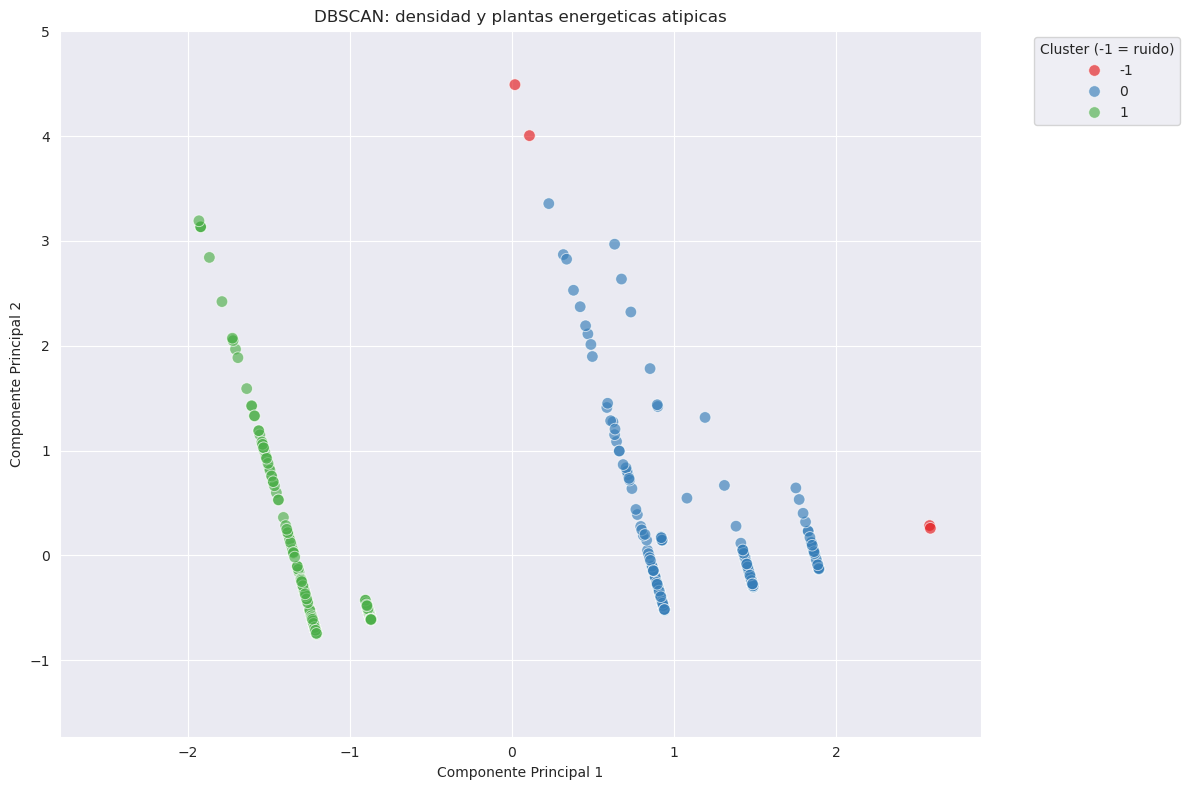

In [10]:
pc1_min, pc1_max = np.percentile(pdf_dbscan["PC1"], [1, 99])
pc2_min, pc2_max = np.percentile(pdf_dbscan["PC2"], [1, 99])

plt.figure(figsize=(12, 8))
sns.set_style("darkgrid")
sns.scatterplot(data=pdf_dbscan, x="PC1", y="PC2", hue="cluster_dbscan", palette="Set1", s=70, alpha=0.65)
plt.xlim(pc1_min - 1, pc1_max + 1)
plt.ylim(pc2_min - 1, pc2_max + 1)
plt.title("DBSCAN: densidad y plantas energeticas atipicas")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster (-1 = ruido)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. Exportacion y conclusiones

Los resultados permiten identificar perfiles de plantas con capacidades y tecnologias similares, junto con posibles outliers que ameritan revision. En una decision organizacional, los clusters pueden apoyar la priorizacion de tecnologias renovables y la revision de instalaciones con capacidades excepcionalmente altas.

In [11]:
salida = Path("salidas")
salida.mkdir(parents=True, exist_ok=True)

pdf_salida = df_clusters.select("item", "pais", "tecnologia", "categoria_energia", "capacidad_mw", "prediction").toPandas()
asignacion_dbscan = pdf_dbscan[["item", "cluster_dbscan"]].drop_duplicates(subset=["item"])
pdf_salida = pdf_salida.merge(asignacion_dbscan, on="item", how="left")
archivo_salida = salida / "clusters_energia_thalia.csv"
pdf_salida.to_csv(archivo_salida, index=False)

print("Archivo exportado:", archivo_salida)
print("Registros exportados:", len(pdf_salida))
print("Conclusion: los clusters segmentan las plantas por capacidad y perfil energetico; DBSCAN identifica casos atipicos para revision.")

Archivo exportado: salidas/clusters_energia_thalia.csv
Registros exportados: 500
Conclusion: los clusters segmentan las plantas por capacidad y perfil energetico; DBSCAN identifica casos atipicos para revision.
